In [2]:
# Module 6: Baseline Models
# NYC Taxi Trip Duration & Congestion Pricing Prediction

# # Module 6: Baseline Models
# **Goal:** Establish baseline performance benchmarks for both models using
# simple strategies and first "real" ML algorithms (Linear Regression & Logistic Regression).
# These baselines set the floor that Module 7's advanced models must beat.

In [3]:
# ============================================================================
# PHASE 1: IMPORTS & DATA LOADING
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
# %% ============================================================================
# PHASE 2: LOAD DATA
# ============================================================================

DATA_PATH = r"C:\Users\hunda\OneDrive\Desktop\Machine Learning Project\processed"

print("=" * 70)
print("PHASE 2: DATA LOADING")
print("=" * 70)

# Load feature-engineered datasets
df_m1 = pd.read_parquet(os.path.join(DATA_PATH, "fe_model1_duration.parquet"))
df_m2 = pd.read_parquet(os.path.join(DATA_PATH, "fe_model2_congestion.parquet"))

print(f"\n📦 Model 1 (Duration Regression):  {df_m1.shape[0]:,} rows × {df_m1.shape[1]} columns")
print(f"📦 Model 2 (Congestion Classification): {df_m2.shape[0]:,} rows × {df_m2.shape[1]} columns")

# Verify targets exist
print(f"\n🎯 Model 1 target: trip_duration_min")
print(f"   Range: {df_m1['trip_duration_min'].min():.2f} — {df_m1['trip_duration_min'].max():.2f} min")
print(f"   Mean:  {df_m1['trip_duration_min'].mean():.2f} min")
print(f"   Median: {df_m1['trip_duration_min'].median():.2f} min")

print(f"\n🎯 Model 2 target: has_congestion_fee")
print(f"   Class 1 (Yes): {df_m2['has_congestion_fee'].mean()*100:.1f}%")
print(f"   Class 0 (No):  {(1 - df_m2['has_congestion_fee'].mean())*100:.1f}%")

# Display all columns for verification
print(f"\n📋 Model 1 columns ({df_m1.shape[1]}):")
print(df_m1.columns.tolist())
print(f"\n📋 Model 2 columns ({df_m2.shape[1]}):")
print(df_m2.columns.tolist())

print("\n✅ Data loaded successfully")

PHASE 2: DATA LOADING

📦 Model 1 (Duration Regression):  2,721,501 rows × 63 columns
📦 Model 2 (Congestion Classification): 2,412,426 rows × 60 columns

🎯 Model 1 target: trip_duration_min
   Range: 1.00 — 179.03 min
   Mean:  14.17 min
   Median: 11.25 min

🎯 Model 2 target: has_congestion_fee
   Class 1 (Yes): 74.6%
   Class 0 (No):  25.4%

📋 Model 1 columns (63):
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'trip_duration_min', 'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'is_weekend', 'is_rush_hour', 'is_peak_hour', 'pickup_hour_sin', 'pickup_hour_cos', 'pickup_dow_sin', 'pickup_dow_cos', 'is_same_zone', 'pu_is_airport', 'do_is_airport', 'is_airport_trip', 'pu_is_cbd', 'do_is_cbd', 'pickup_zone_popularity', 'dropoff_zone_popularity', 'log_trip_distance', 'is_single_passenger', 'is_extreme_distance', 'is_extreme_fare', 'pay_1', 'pay_2', 'rate_1.0', 'rate_2.0', 'rate_3.0', 'rate_4.0', 

In [5]:
# %% ============================================================================
# PHASE 3: TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 3: TRAIN-TEST SPLIT (80/20)")
print("=" * 70)

# --- MODEL 1: Duration Regression ---
TARGET_M1 = 'trip_duration_min'
X_m1 = df_m1.drop(columns=[TARGET_M1])
y_m1 = df_m1[TARGET_M1]

X_train_m1, X_test_m1, y_train_m1, y_test_m1 = train_test_split(
    X_m1, y_m1, test_size=0.20, random_state=42
)

print(f"\n📊 Model 1 — Duration Regression:")
print(f"   Training set: {X_train_m1.shape[0]:,} rows × {X_train_m1.shape[1]} features")
print(f"   Test set:     {X_test_m1.shape[0]:,} rows × {X_test_m1.shape[1]} features")
print(f"   Train target mean: {y_train_m1.mean():.2f} min")
print(f"   Test target mean:  {y_test_m1.mean():.2f} min")


PHASE 3: TRAIN-TEST SPLIT (80/20)

📊 Model 1 — Duration Regression:
   Training set: 2,177,200 rows × 62 features
   Test set:     544,301 rows × 62 features
   Train target mean: 14.18 min
   Test target mean:  14.16 min


In [6]:
# --- MODEL 2: Congestion Classification ---
TARGET_M2 = 'has_congestion_fee'
X_m2 = df_m2.drop(columns=[TARGET_M2])
y_m2 = df_m2[TARGET_M2]

# Stratified split to preserve class balance
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2, test_size=0.20, random_state=42, stratify=y_m2
)

print(f"\n📊 Model 2 — Congestion Classification:")
print(f"   Training set: {X_train_m2.shape[0]:,} rows × {X_train_m2.shape[1]} features")
print(f"   Test set:     {X_test_m2.shape[0]:,} rows × {X_test_m2.shape[1]} features")
print(f"   Train class balance: {y_train_m2.mean()*100:.1f}% positive")
print(f"   Test class balance:  {y_test_m2.mean()*100:.1f}% positive")

print("\n✅ Train-test split complete")


📊 Model 2 — Congestion Classification:
   Training set: 1,929,940 rows × 59 features
   Test set:     482,486 rows × 59 features
   Train class balance: 74.6% positive
   Test class balance:  74.6% positive

✅ Train-test split complete


In [7]:
# %% ============================================================================
# PHASE 4: FEATURE SCALING
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 4: FEATURE SCALING (StandardScaler)")
print("=" * 70)
print("\nWhy scale? Linear & Logistic Regression are sensitive to feature magnitudes.")
print("A feature ranging 0-150,000 would dominate one ranging 0-1.")
print("StandardScaler transforms each feature to mean=0, std=1.")
print("⚠️  Fitted on TRAINING data only, then applied to test (prevents leakage).")

# --- Model 1 Scaling ---
scaler_m1 = StandardScaler()
X_train_m1_scaled = pd.DataFrame(
    scaler_m1.fit_transform(X_train_m1),
    columns=X_train_m1.columns,
    index=X_train_m1.index
)
X_test_m1_scaled = pd.DataFrame(
    scaler_m1.transform(X_test_m1),
    columns=X_test_m1.columns,
    index=X_test_m1.index
)


PHASE 4: FEATURE SCALING (StandardScaler)

Why scale? Linear & Logistic Regression are sensitive to feature magnitudes.
A feature ranging 0-150,000 would dominate one ranging 0-1.
StandardScaler transforms each feature to mean=0, std=1.
⚠️  Fitted on TRAINING data only, then applied to test (prevents leakage).


In [8]:
# --- Model 2 Scaling ---
scaler_m2 = StandardScaler()
X_train_m2_scaled = pd.DataFrame(
    scaler_m2.fit_transform(X_train_m2),
    columns=X_train_m2.columns,
    index=X_train_m2.index
)
X_test_m2_scaled = pd.DataFrame(
    scaler_m2.transform(X_test_m2),
    columns=X_test_m2.columns,
    index=X_test_m2.index
)

print(f"\n📐 Model 1 — Scaled feature sample (first 5 cols, train):")
print(X_train_m1_scaled.iloc[:3, :5].round(3).to_string())
print(f"\n📐 Model 2 — Scaled feature sample (first 5 cols, train):")
print(X_train_m2_scaled.iloc[:3, :5].round(3).to_string())

print("\n✅ Feature scaling complete")


📐 Model 1 — Scaled feature sample (first 5 cols, train):
         passenger_count  trip_distance  PULocationID  DOLocationID  congestion_surcharge
1744407           -0.415          3.767        -0.445        -0.509                 0.238
1561901            0.925          0.236        -0.877         1.007                 0.238
1236014           -0.415         -0.238        -0.414         1.386                 0.238

📐 Model 2 — Scaled feature sample (first 5 cols, train):
         passenger_count  trip_distance  PULocationID  DOLocationID  pickup_hour
1985193           -0.399         -0.545        -0.086        -0.371       -0.090
875786            -0.399         -0.552        -0.454         1.398       -0.822
1444564           -0.399         -0.301        -0.102         1.003        0.459

✅ Feature scaling complete


In [9]:
# %% ============================================================================
# PHASE 5: MODEL 1 — BASELINE MODELS (Duration Regression)
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 5: MODEL 1 — DURATION REGRESSION BASELINES")
print("=" * 70)

# ---- Helper function for regression metrics ----
def eval_regression(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n📊 {model_name}")
    print(f"   MAE:  {mae:.2f} min  (avg error — off by this many minutes)")
    print(f"   RMSE: {rmse:.2f} min  (penalizes large errors more)")
    print(f"   R²:   {r2:.4f}       (1.0 = perfect, 0.0 = same as mean)")
    return {'model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


PHASE 5: MODEL 1 — DURATION REGRESSION BASELINES


In [10]:
# ---- Baseline 1: Always predict the MEAN ----
print("\n--- Baseline 1: Predict Mean (Dumb Baseline) ---")
mean_pred = np.full(len(y_test_m1), y_train_m1.mean())
results_m1 = []
results_m1.append(eval_regression(y_test_m1, mean_pred, "Predict Mean"))

# ---- Baseline 2: Always predict the MEDIAN ----
print("\n--- Baseline 2: Predict Median ---")
median_pred = np.full(len(y_test_m1), y_train_m1.median())
results_m1.append(eval_regression(y_test_m1, median_pred, "Predict Median"))

# ---- Baseline 3: Linear Regression ----
print("\n--- Baseline 3: Linear Regression ---")
t_start = time.time()
lr_model = LinearRegression()
lr_model.fit(X_train_m1_scaled, y_train_m1)
lr_pred = lr_model.predict(X_test_m1_scaled)
t_lr = time.time() - t_start
results_m1.append(eval_regression(y_test_m1, lr_pred, "Linear Regression"))
print(f"   Training time: {t_lr:.1f} seconds")


--- Baseline 1: Predict Mean (Dumb Baseline) ---

📊 Predict Mean
   MAE:  7.59 min  (avg error — off by this many minutes)
   RMSE: 10.72 min  (penalizes large errors more)
   R²:   -0.0000       (1.0 = perfect, 0.0 = same as mean)

--- Baseline 2: Predict Median ---

📊 Predict Median
   MAE:  7.19 min  (avg error — off by this many minutes)
   RMSE: 11.11 min  (penalizes large errors more)
   R²:   -0.0738       (1.0 = perfect, 0.0 = same as mean)

--- Baseline 3: Linear Regression ---

📊 Linear Regression
   MAE:  3.23 min  (avg error — off by this many minutes)
   RMSE: 4.89 min  (penalizes large errors more)
   R²:   0.7921       (1.0 = perfect, 0.0 = same as mean)
   Training time: 7.1 seconds


In [11]:
# ---- Model 1 Results Summary ----
print("\n" + "-" * 60)
print("MODEL 1 — BASELINE COMPARISON")
print("-" * 60)
df_results_m1 = pd.DataFrame(results_m1)
print(df_results_m1.to_string(index=False))

# Stakeholder check
best_rmse = df_results_m1['RMSE'].min()
print(f"\n🎯 Stakeholder target: RMSE < 10 minutes")
print(f"   Best baseline RMSE: {best_rmse:.2f} minutes")
if best_rmse < 10:
    print(f"   ✅ Already meets target! But advanced models may improve further.")
else:
    print(f"   ⚠️  Not yet meeting target. Advanced models in Module 7 needed.")


------------------------------------------------------------
MODEL 1 — BASELINE COMPARISON
------------------------------------------------------------
            model      MAE      RMSE        R2
     Predict Mean 7.593365 10.719017 -0.000002
   Predict Median 7.185459 11.107673 -0.073834
Linear Regression 3.231724  4.887590  0.792088

🎯 Stakeholder target: RMSE < 10 minutes
   Best baseline RMSE: 4.89 minutes
   ✅ Already meets target! But advanced models may improve further.


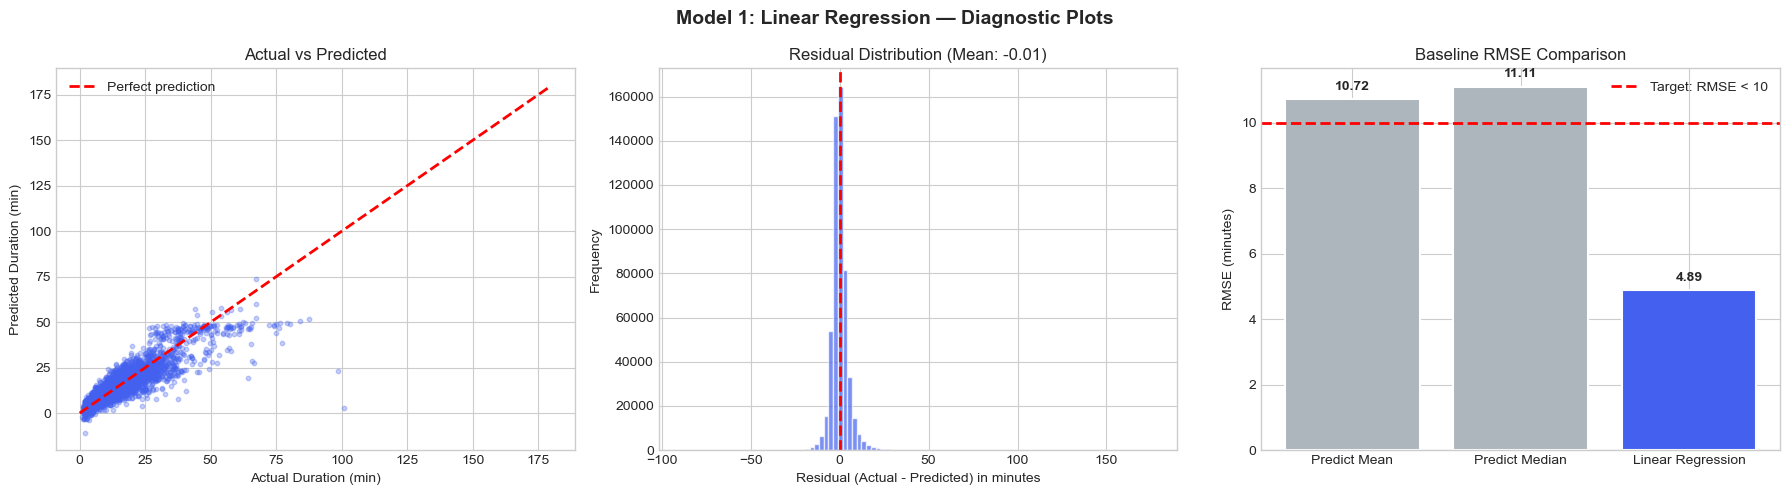

✅ Model 1 diagnostic plots saved


In [12]:
# %% ============================================================================
# PHASE 5 VISUAL: Model 1 — Actual vs Predicted & Residuals
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model 1: Linear Regression — Diagnostic Plots', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted (sample for speed)
sample_idx = np.random.RandomState(42).choice(len(y_test_m1), size=5000, replace=False)
y_test_sample = y_test_m1.iloc[sample_idx]
lr_pred_sample = lr_pred[sample_idx]

axes[0].scatter(y_test_sample, lr_pred_sample, alpha=0.3, s=10, color='#4361ee')
axes[0].plot([0, 180], [0, 180], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Duration (min)')
axes[0].set_ylabel('Predicted Duration (min)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Plot 2: Residual Distribution
residuals = y_test_m1 - lr_pred
axes[1].hist(residuals, bins=100, color='#4361ee', alpha=0.7, edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted) in minutes')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual Distribution (Mean: {residuals.mean():.2f})')

# Plot 3: Baseline Comparison Bar Chart
models = df_results_m1['model'].tolist()
rmse_vals = df_results_m1['RMSE'].tolist()
colors = ['#adb5bd', '#adb5bd', '#4361ee']
bars = axes[2].bar(models, rmse_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[2].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Target: RMSE < 10')
axes[2].set_ylabel('RMSE (minutes)')
axes[2].set_title('Baseline RMSE Comparison')
axes[2].legend()
for bar, val in zip(bars, rmse_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, '..', 'model1_baseline_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model 1 diagnostic plots saved")

In [13]:
# %% ============================================================================
# PHASE 6: MODEL 2 — BASELINE MODELS (Congestion Classification)
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 6: MODEL 2 — CONGESTION CLASSIFICATION BASELINES")
print("=" * 70)

# ---- Helper function for classification metrics ----
def eval_classification(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.0

    print(f"\n📊 {model_name}")
    print(f"   Accuracy:  {acc:.4f}  (overall correct predictions)")
    print(f"   Precision: {prec:.4f}  (of predicted YES, how many correct)")
    print(f"   Recall:    {rec:.4f}  (of actual YES, how many caught)")
    print(f"   F1 Score:  {f1:.4f}  (balance of precision & recall)")
    print(f"   AUC-ROC:   {auc:.4f}  (overall discrimination ability)")
    return {'model': model_name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

# ---- Baseline 1: Always predict MAJORITY class (1 = has fee) ----
print("\n--- Baseline 1: Always Predict Majority Class (1 = Yes) ---")
majority_pred = np.ones(len(y_test_m2), dtype=int)
majority_prob = np.ones(len(y_test_m2))  # 100% confidence in class 1
results_m2 = []
results_m2.append(eval_classification(y_test_m2, majority_pred, majority_prob, "Predict Majority (Always Yes)"))
print("\n   Confusion Matrix:")
print(confusion_matrix(y_test_m2, majority_pred))
print("   ↑ Notice: ZERO correct predictions for class 0 (No fee)")

# ---- Baseline 2: Logistic Regression ----
print("\n--- Baseline 2: Logistic Regression ---")
t_start = time.time()
log_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
log_model.fit(X_train_m2_scaled, y_train_m2)
log_pred = log_model.predict(X_test_m2_scaled)
log_prob = log_model.predict_proba(X_test_m2_scaled)[:, 1]
t_log = time.time() - t_start
results_m2.append(eval_classification(y_test_m2, log_pred, log_prob, "Logistic Regression"))
print(f"   Training time: {t_log:.1f} seconds")

print("\n   Classification Report:")
print(classification_report(y_test_m2, log_pred, target_names=['No Fee (0)', 'Has Fee (1)']))

print("   Confusion Matrix:")
cm = confusion_matrix(y_test_m2, log_pred)
print(cm)

# ---- Model 2 Results Summary ----
print("\n" + "-" * 60)
print("MODEL 2 — BASELINE COMPARISON")
print("-" * 60)
df_results_m2 = pd.DataFrame(results_m2)
print(df_results_m2.to_string(index=False))

# Stakeholder check
best_acc = df_results_m2['Accuracy'].max()
print(f"\n🎯 Stakeholder target: Accuracy > 85%")
print(f"   Best baseline accuracy: {best_acc*100:.1f}%")
if best_acc > 0.85:
    print(f"   ✅ Already meets target! But F1 and AUC matter more for imbalanced data.")
else:
    print(f"   ⚠️  Not yet meeting target. Advanced models in Module 7 needed.")


PHASE 6: MODEL 2 — CONGESTION CLASSIFICATION BASELINES

--- Baseline 1: Always Predict Majority Class (1 = Yes) ---

📊 Predict Majority (Always Yes)
   Accuracy:  0.7455  (overall correct predictions)
   Precision: 0.7455  (of predicted YES, how many correct)
   Recall:    1.0000  (of actual YES, how many caught)
   F1 Score:  0.8542  (balance of precision & recall)
   AUC-ROC:   0.5000  (overall discrimination ability)

   Confusion Matrix:
[[     0 122788]
 [     0 359698]]
   ↑ Notice: ZERO correct predictions for class 0 (No fee)

--- Baseline 2: Logistic Regression ---

📊 Logistic Regression
   Accuracy:  0.9361  (overall correct predictions)
   Precision: 0.9414  (of predicted YES, how many correct)
   Recall:    0.9751  (of actual YES, how many caught)
   F1 Score:  0.9579  (balance of precision & recall)
   AUC-ROC:   0.9636  (overall discrimination ability)
   Training time: 8.5 seconds

   Classification Report:
              precision    recall  f1-score   support

  No Fee

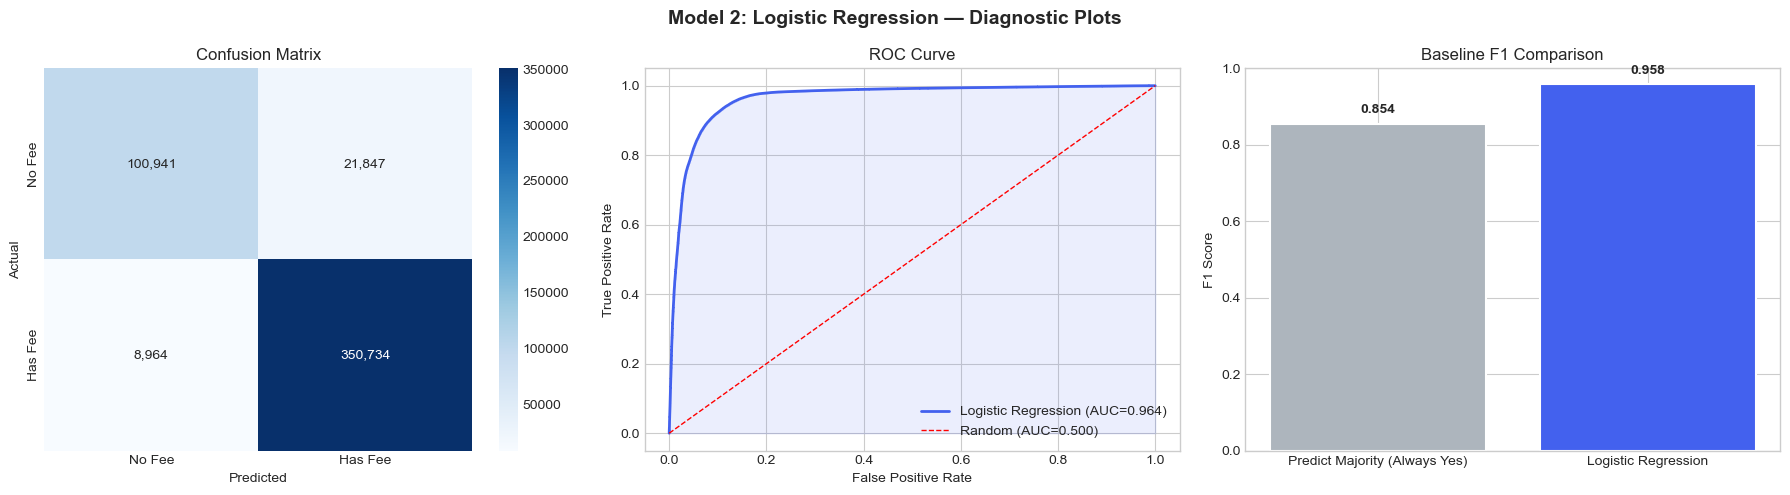

✅ Model 2 diagnostic plots saved


In [14]:
# %% ============================================================================
# PHASE 6 VISUAL: Model 2 — Confusion Matrix & ROC Curve
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model 2: Logistic Regression — Diagnostic Plots', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[0],
            xticklabels=['No Fee', 'Has Fee'], yticklabels=['No Fee', 'Has Fee'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_m2, log_prob)
auc_val = roc_auc_score(y_test_m2, log_prob)
axes[1].plot(fpr, tpr, color='#4361ee', linewidth=2, label=f'Logistic Regression (AUC={auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC=0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4361ee')

# Plot 3: Baseline Comparison — F1 Score
models_m2 = df_results_m2['model'].tolist()
f1_vals = df_results_m2['F1'].tolist()
colors = ['#adb5bd', '#4361ee']
bars = axes[2].bar(models_m2, f1_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Baseline F1 Comparison')
axes[2].set_ylim(0, 1.0)
for bar, val in zip(bars, f1_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, '..', 'model2_baseline_diagnostics.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model 2 diagnostic plots saved")


PHASE 7: FEATURE IMPORTANCE ANALYSIS

📊 Model 1 — Linear Regression: Top 15 Most Important Features
pax_1                   6.908031e+12
pax_2                   4.582994e+12
pax_3+                  3.159999e+12
period_afternoon        2.690686e+12
period_evening          2.568681e+12
period_morning          2.386393e+12
period_night            2.014256e+12
is_single_passenger     1.618757e+12
cbd_out_of_cbd          1.494736e+12
period_early_morning    1.430995e+12
do_is_cbd               1.355975e+12
cbd_outside_cbd         1.209660e+12
do_cluster_high         1.113973e+12
do_cluster_medium       1.036307e+12
rate_1.0                9.435193e+11

📊 Model 2 — Logistic Regression: Top 15 Most Important Features
log_trip_distance         1.3973
cbd_outside_cbd           1.0543
pu_is_cbd                 0.9378
cbd_within_cbd            0.8780
do_is_cbd                 0.8721
trip_distance             0.3847
PULocationID              0.3283
pu_is_airport             0.2525
DOLocationID   

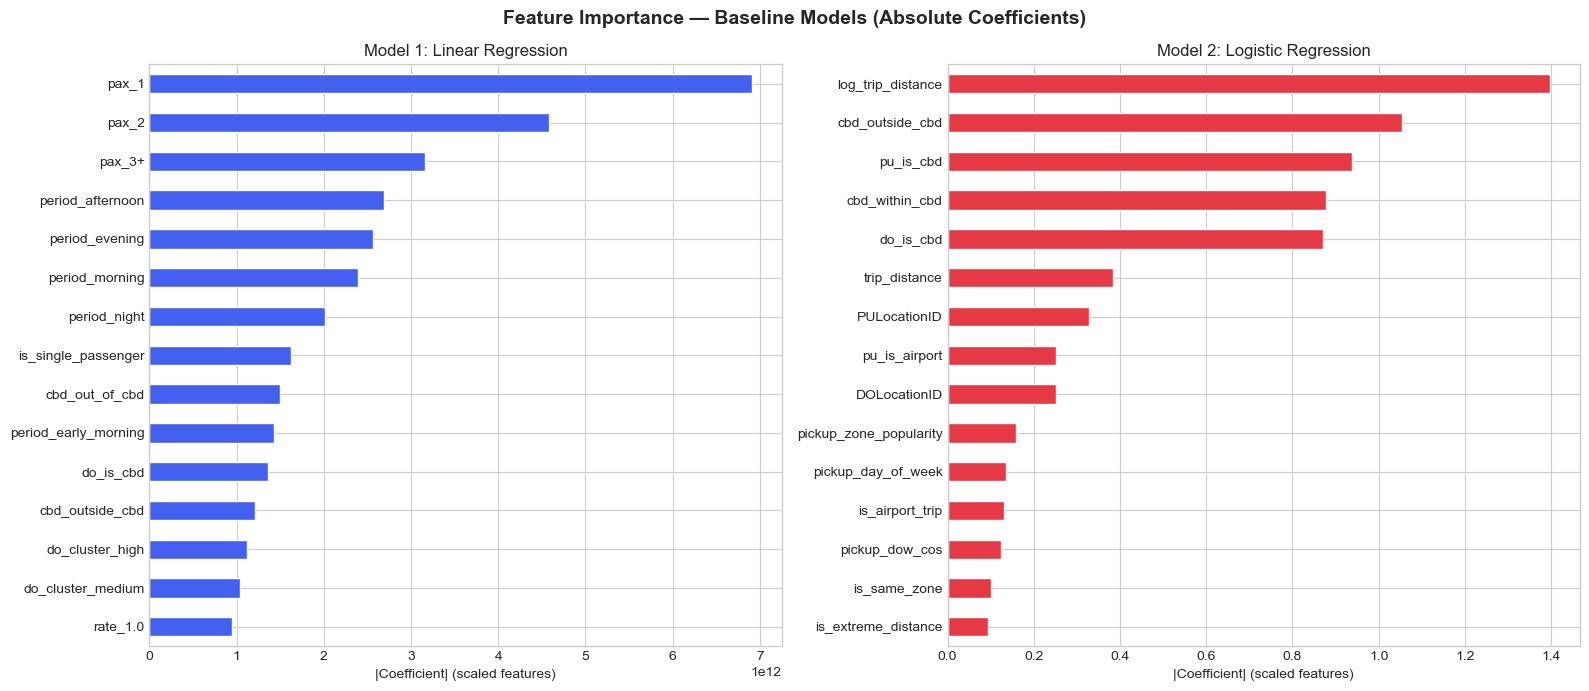

✅ Feature importance plots saved


In [15]:
# %% ============================================================================
# PHASE 7: FEATURE IMPORTANCE — LINEAR REGRESSION (Model 1)
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 7: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# --- Model 1: Linear Regression Coefficients ---
print("\n📊 Model 1 — Linear Regression: Top 15 Most Important Features")
coef_m1 = pd.Series(np.abs(lr_model.coef_), index=X_train_m1.columns)
top15_m1 = coef_m1.sort_values(ascending=False).head(15)
print(top15_m1.round(4).to_string())

# --- Model 2: Logistic Regression Coefficients ---
print("\n📊 Model 2 — Logistic Regression: Top 15 Most Important Features")
coef_m2 = pd.Series(np.abs(log_model.coef_[0]), index=X_train_m2.columns)
top15_m2 = coef_m2.sort_values(ascending=False).head(15)
print(top15_m2.round(4).to_string())

# ---- Feature Importance Visualization ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance — Baseline Models (Absolute Coefficients)', fontsize=14, fontweight='bold')

top15_m1.sort_values().plot(kind='barh', ax=axes[0], color='#4361ee', edgecolor='white')
axes[0].set_title('Model 1: Linear Regression')
axes[0].set_xlabel('|Coefficient| (scaled features)')

top15_m2.sort_values().plot(kind='barh', ax=axes[1], color='#e63946', edgecolor='white')
axes[1].set_title('Model 2: Logistic Regression')
axes[1].set_xlabel('|Coefficient| (scaled features)')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, '..', 'baseline_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plots saved")

In [16]:
# %% ============================================================================
# PHASE 8: FINAL SUMMARY & SAVE RESULTS
# ============================================================================

print("\n" + "=" * 70)
print("PHASE 8: MODULE 6 — FINAL SUMMARY")
print("=" * 70)

print("\n" + "=" * 70)
print("MODEL 1 — DURATION REGRESSION RESULTS")
print("=" * 70)
print(df_results_m1.to_string(index=False))
print(f"\n🏆 Best model: {df_results_m1.loc[df_results_m1['RMSE'].idxmin(), 'model']}")
print(f"   RMSE: {df_results_m1['RMSE'].min():.2f} min | R²: {df_results_m1.loc[df_results_m1['RMSE'].idxmin(), 'R2']:.4f}")

print("\n" + "=" * 70)
print("MODEL 2 — CONGESTION CLASSIFICATION RESULTS")
print("=" * 70)
print(df_results_m2.to_string(index=False))
print(f"\n🏆 Best model: {df_results_m2.loc[df_results_m2['F1'].idxmax(), 'model']}")
print(f"   F1: {df_results_m2['F1'].max():.4f} | AUC-ROC: {df_results_m2.loc[df_results_m2['F1'].idxmax(), 'AUC-ROC']:.4f}")

print("\n" + "=" * 70)
print("PERFORMANCE vs STAKEHOLDER TARGETS")
print("=" * 70)
print(f"\n   Model 1 Target: RMSE < 10 min  →  Current: {df_results_m1['RMSE'].min():.2f} min", end="")
print(f"  {'✅ MET' if df_results_m1['RMSE'].min() < 10 else '⚠️  NOT MET — Module 7 needed'}")
print(f"   Model 2 Target: Acc > 85%      →  Current: {df_results_m2['Accuracy'].max()*100:.1f}%", end="")
print(f"  {'✅ MET' if df_results_m2['Accuracy'].max() > 0.85 else '⚠️  NOT MET — Module 7 needed'}")

# ---- Save results for Module 7 reference ----
SAVE_PATH = os.path.join(DATA_PATH, '..', 'processed')

# Save baseline results
df_results_m1.to_csv(os.path.join(SAVE_PATH, 'baseline_results_model1.csv'), index=False)
df_results_m2.to_csv(os.path.join(SAVE_PATH, 'baseline_results_model2.csv'), index=False)

# Save train/test splits for consistent use in Module 7
np.savez(os.path.join(SAVE_PATH, 'train_test_split_m1.npz'),
         X_train=X_train_m1.values, X_test=X_test_m1.values,
         y_train=y_train_m1.values, y_test=y_test_m1.values)
np.savez(os.path.join(SAVE_PATH, 'train_test_split_m2.npz'),
         X_train=X_train_m2.values, X_test=X_test_m2.values,
         y_train=y_train_m2.values, y_test=y_test_m2.values)

# Save column names for Module 7
pd.Series(X_train_m1.columns.tolist()).to_csv(os.path.join(SAVE_PATH, 'feature_names_m1.csv'), index=False)
pd.Series(X_train_m2.columns.tolist()).to_csv(os.path.join(SAVE_PATH, 'feature_names_m2.csv'), index=False)

print("\n📁 Files saved to processed/:")
print("   ✅ baseline_results_model1.csv")
print("   ✅ baseline_results_model2.csv")
print("   ✅ train_test_split_m1.npz")
print("   ✅ train_test_split_m2.npz")
print("   ✅ feature_names_m1.csv")
print("   ✅ feature_names_m2.csv")

print("\n📊 Plots saved:")
print("   ✅ model1_baseline_diagnostics.png")
print("   ✅ model2_baseline_diagnostics.png")
print("   ✅ baseline_feature_importance.png")

print("\n" + "=" * 70)
print("✅ MODULE 6: BASELINE MODELS — COMPLETE")
print("=" * 70)
print("\nNext Step: Module 7 — Advanced Models 🚀")
print("(Random Forest, XGBoost, and hyperparameter tuning)")


PHASE 8: MODULE 6 — FINAL SUMMARY

MODEL 1 — DURATION REGRESSION RESULTS
            model      MAE      RMSE        R2
     Predict Mean 7.593365 10.719017 -0.000002
   Predict Median 7.185459 11.107673 -0.073834
Linear Regression 3.231724  4.887590  0.792088

🏆 Best model: Linear Regression
   RMSE: 4.89 min | R²: 0.7921

MODEL 2 — CONGESTION CLASSIFICATION RESULTS
                        model  Accuracy  Precision   Recall       F1  AUC-ROC
Predict Majority (Always Yes)  0.745510   0.745510 1.000000 0.854203 0.500000
          Logistic Regression  0.936141   0.941363 0.975079 0.957925 0.963628

🏆 Best model: Logistic Regression
   F1: 0.9579 | AUC-ROC: 0.9636

PERFORMANCE vs STAKEHOLDER TARGETS

   Model 1 Target: RMSE < 10 min  →  Current: 4.89 min  ✅ MET
   Model 2 Target: Acc > 85%      →  Current: 93.6%  ✅ MET

📁 Files saved to processed/:
   ✅ baseline_results_model1.csv
   ✅ baseline_results_model2.csv
   ✅ train_test_split_m1.npz
   ✅ train_test_split_m2.npz
   ✅ feature_nam